In [ ]:
# Installaing all the machine learning libraries required for this project.
# -q means quiet mode, this helps installation logs stay clean and minimal.
# These libraries help in training advanced prediction models and explaining model outputs.
!pip install -q catboost lightgbm xgboost shap


In [ ]:
# =========================================================
# Importing Basic Libraries
# These libraries are used for data handling, calculations,
# and data visualization.
# =========================================================

import pandas as pd          # Used for handling datasets and tables (DataFrames)
import numpy as np           # Used for numerical operations and array calculations
import matplotlib.pyplot as plt   # Used for creating graphs and plots
import seaborn as sns        # Used for advanced and attractive data visualizations


# =========================================================
# Importing Libraries for Machine Learning & Model Building
# These libraries help in training, testing, and improving
# machine learning models.
# =========================================================

from sklearn.model_selection import train_test_split, GridSearchCV
# train_test_split -> splits dataset into training and testing data
# GridSearchCV -> helps find the best model parameters automatically

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# LinearRegression -> basic regression model for prediction
# Ridge, Lasso, ElasticNet -> advanced regression models to reduce overfitting

from sklearn.ensemble import GradientBoostingRegressor
# Ensemble learning model that improves prediction accuracy

from xgboost import XGBRegressor
# Powerful boosting algorithm widely used in ML competitions

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
# r2_score -> checks model accuracy/performance
# mean_squared_error -> calculates prediction error
# mean_absolute_error -> average prediction error
# accuracy_score -> mainly used for classification models

from sklearn.model_selection import KFold, cross_val_score
# KFold -> splits data into multiple folds for validation
# cross_val_score -> evaluates model performance using cross validation

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
# LabelEncoder -> converts text data into numbers
# MinMaxScaler -> scales values between 0 and 1
# StandardScaler -> standardizes data for better model performance

from sklearn.tree import DecisionTreeRegressor
# Decision Tree model used for regression predictions

from sklearn.datasets import make_regression
# Creates sample regression datasets for testing

from sklearn.pipeline import Pipeline
# Helps combine multiple ML steps into one workflow

import lightgbm as lgb
# LightGBM -> fast gradient boosting framework for high accuracy

import catboost as cb
# CatBoost -> boosting algorithm especially good for categorical data

import shap
# SHAP -> explains how the ML model makes predictions

from sklearn.ensemble import StackingRegressor
# Combines multiple ML models together for better predictions


# =========================================================
# Ignore Warning Messages
# Keeps notebook output clean and readable
# =========================================================

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# =========================================================
# Function to Calculate Adjusted R² Score
# Adjusted R² is used to measure how well the model fits
# the data while also considering the number of features used.
# =========================================================

def adjusted_r2_score(y_true, y_pred, n_features):

    # Calculate the normal R² score
    # R² tells how much variance in the target variable
    # is explained by the model.
    r2 = r2_score(y_true, y_pred)

    # Find the total number of samples/data points
    n_samples = len(y_true)

    # Calculate Adjusted R² Score
    # This penalizes unnecessary features in the model.
    # Helps avoid overfitting.
    adj_r2 = 1 - ((1 - r2) * (n_samples - 1) / (n_samples - n_features - 1))

    # Return the final adjusted R² value
    return adj_r2

In [ ]:
# =========================================================
# Customizing Pandas Display Settings
# These settings improve the readability of dataset outputs.
# =========================================================

# Show all columns in the dataset output
# By default, pandas hides some columns if there are too many.
pd.options.display.max_columns = None


# Display float values in normal decimal format
# instead of scientific/exponent notation.
# Example:
# 1200000.00 instead of 1.2e+06
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
import pandas as pd

file_name = 'Bengaluru_House_Data.csv'

raw_data = pd.read_csv(file_name)

raw_data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.00,1.00,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.00,3.00,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.00,3.00,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.00,1.00,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.00,1.00,51.00


In [ ]:
# Reading zip_codes CSV where city names will be taken from
# IMPORTANT: Upload zip_codes_ml.csv in the same folder/runtime before running this cell.
#import os
#if not os.path.exists('zip_codes_ml.csv'):
   # raise FileNotFoundError("zip_codes_ml.csv not found. Upload zip_codes_ml.csv to Colab Files or keep it in the same project folder.")

#zip_codes = pd.read_csv('zip_codes_ml.csv')
#zip_codes.head()


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
raw_data.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


# **1. Data cleaning and preprocessing**

### **Data inspection**


In [ ]:
#Inspecting the columns of the data set
raw_data.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [ ]:
#Inspecting the data types of all the columns of the data set
raw_data.dtypes

,0
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64


In [ ]:
#Inspecting the shape of raw data
raw_data.shape

(13320, 9)

In [ ]:
#Getting the meta information of the housing data
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
#Printing the statistical inference for the data set
raw_data.describe()

,bath,balcony,price
count,13247.00,12711.00,13320.00
mean,2.69,1.58,112.57
std,1.34,0.82,148.97
min,1.00,0.00,8.00
25%,2.00,1.00,50.00
50%,2.00,2.00,72.00
75%,3.00,2.00,120.00
max,40.00,3.00,3600.00


In [ ]:
#Counting the null values in each column
raw_data.isna().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


## Removing unwanted variables


In [ ]:
# Creating a copy of raw data
processing_data = raw_data.copy()

# Columns we want to remove if they exist
columns_to_remove = ['cid', 'yr_renovated', 'lat', 'long', 'society']

# Remove only those columns which are present in the dataset
processing_data = processing_data.drop(columns=columns_to_remove, errors='ignore')

# Show remaining columns
processing_data.columns

Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='object')

In [ ]:
#printing the dataset columns after removal of unwanted columns
processing_data.columns

Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='object')

## Null values and inappropriate values treatment

In [ ]:
# Creating a copy of raw dataset
processing_data = raw_data.copy()

# Removing society column because it has many missing values
processing_data = processing_data.drop(['society'], axis=1)

# Removing rows where important values are missing
processing_data = processing_data.dropna(subset=['location', 'size', 'bath', 'total_sqft'])

# Filling missing balcony values with median
processing_data['balcony'] = processing_data['balcony'].fillna(processing_data['balcony'].median())

# Converting size column like "2 BHK" into only number 2
processing_data['bhk'] = processing_data['size'].apply(lambda x: int(x.split(' ')[0]))

# Removing original size column after creating bhk
processing_data = processing_data.drop(['size'], axis=1)

# Showing cleaned data
processing_data.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.00,1.00,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.00,3.00,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.00,3.00,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.00,1.00,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.00,1.00,51.00,2


In [ ]:
#Checking whether null values are still there after the null values treatment
processing_data.isna().sum()

,0
area_type,0
availability,0
location,0
total_sqft,0
bath,0
balcony,0
price,0
bhk,0




> Add blockquote



No null values are being found after the treatment

## Feature generation and transformation

In [ ]:
# Checking dataset columns
processing_data.columns

Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'price', 'bhk'],
      dtype='object')

In [ ]:
# Convert total_sqft values safely into numbers
def convert_sqft_to_num(x):
    x = str(x)

    # If value is range like "2100 - 2850", take average
    if '-' in x:
        tokens = x.split('-')
        return (float(tokens[0]) + float(tokens[1])) / 2

    # Try normal conversion
    try:
        return float(x)
    except:
        return None


# Apply conversion
processing_data['total_sqft'] = processing_data['total_sqft'].apply(convert_sqft_to_num)

# Remove rows where total_sqft could not be converted
processing_data = processing_data.dropna(subset=['total_sqft'])

# Create price per sqft
processing_data['price_per_sqft'] = (
    processing_data['price'] * 100000 / processing_data['total_sqft']
)

processing_data.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.00,2.00,1.00,39.07,2,3699.81
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.00,5.00,3.00,120.00,4,4615.38
2,Built-up Area,Ready To Move,Uttarahalli,1440.00,2.00,3.00,62.00,3,4305.56
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.00,3.00,1.00,95.00,3,6245.89
4,Super built-up Area,Ready To Move,Kothanur,1200.00,2.00,1.00,51.00,2,4250.00


In [ ]:
# Creating bathroom per BHK feature
processing_data['bath_per_bhk'] = (
    processing_data['bath'] / processing_data['bhk']
)

# Creating balcony per BHK feature
processing_data['balcony_per_bhk'] = (
    processing_data['balcony'] / processing_data['bhk']
)

processing_data.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,bath_per_bhk,balcony_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.00,2.00,1.00,39.07,2,3699.81,1.00,0.50
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.00,5.00,3.00,120.00,4,4615.38,1.25,0.75
2,Built-up Area,Ready To Move,Uttarahalli,1440.00,2.00,3.00,62.00,3,4305.56,0.67,1.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.00,3.00,1.00,95.00,3,6245.89,1.00,0.33
4,Super built-up Area,Ready To Move,Kothanur,1200.00,2.00,1.00,51.00,2,4250.00,1.00,0.50


In [ ]:
#verifying that the newly added features are correctly added
processing_data.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,bath_per_bhk,balcony_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.00,2.00,1.00,39.07,2,3699.81,1.00,0.50
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.00,5.00,3.00,120.00,4,4615.38,1.25,0.75
2,Built-up Area,Ready To Move,Uttarahalli,1440.00,2.00,3.00,62.00,3,4305.56,0.67,1.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.00,3.00,1.00,95.00,3,6245.89,1.00,0.33
4,Super built-up Area,Ready To Move,Kothanur,1200.00,2.00,1.00,51.00,2,4250.00,1.00,0.50


In [ ]:
processing_data['balcony'] = processing_data['balcony'].fillna(0)

processing_data['total_rooms'] = processing_data['bhk'] + processing_data['bath']
processing_data['balcony_ratio'] = processing_data['balcony'] / processing_data['bhk']

processing_data.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,bath_per_bhk,balcony_per_bhk,total_rooms,balcony_ratio
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.00,2.00,1.00,39.07,2,3699.81,1.00,0.50,4.00,0.50
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.00,5.00,3.00,120.00,4,4615.38,1.25,0.75,9.00,0.75
2,Built-up Area,Ready To Move,Uttarahalli,1440.00,2.00,3.00,62.00,3,4305.56,0.67,1.00,5.00,1.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.00,3.00,1.00,95.00,3,6245.89,1.00,0.33,6.00,0.33
4,Super built-up Area,Ready To Move,Kothanur,1200.00,2.00,1.00,51.00,2,4250.00,1.00,0.50,4.00,0.50


In [ ]:
# Creating BHK category feature
bhk_ranges = [0, 2, 4, 6, 100]
bhk_labels = ['Small', 'Medium', 'Large', 'Luxury']

processing_data['bhk_category'] = pd.cut(
    processing_data['bhk'],
    bins=bhk_ranges,
    labels=bhk_labels,
    right=False
)

processing_data['bhk_category']

,bhk_category
0,Medium
1,Large
2,Medium
3,Medium
4,Medium
...,...
13315,Large
13316,Large
13317,Medium
13318,Large


In [ ]:
# Start fresh from raw_data
processing_data = raw_data.copy()

# Drop society column safely
processing_data = processing_data.drop(['society'], axis=1, errors='ignore')

# Remove missing important rows
processing_data = processing_data.dropna(subset=['location', 'size', 'bath', 'total_sqft'])

# Fill balcony missing values
processing_data['balcony'] = processing_data['balcony'].fillna(0)

# Create BHK column
processing_data['bhk'] = processing_data['size'].apply(lambda x: int(x.split(' ')[0]))

# Drop size column
processing_data = processing_data.drop(['size'], axis=1)

# Clean location names
processing_data['location'] = processing_data['location'].str.strip()

# Check output
processing_data.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.00,1.00,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.00,3.00,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.00,3.00,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.00,1.00,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.00,1.00,51.00,2


In [ ]:
# Checking top locations
processing_data['location'].value_counts().head(10)

,count
location,
Whitefield,535
Sarjapur Road,392
Electronic City,304
Kanakpura Road,266
Thanisandra,236
Yelahanka,210
Uttarahalli,186
Hebbal,176
Marathahalli,175


In [ ]:
# Fill missing location values with most frequent location
processing_data['location'] = processing_data['location'].fillna(
    processing_data['location'].mode()[0]
)

processing_data['location'].isna().sum()

np.int64(0)

## **Outlier treatment**

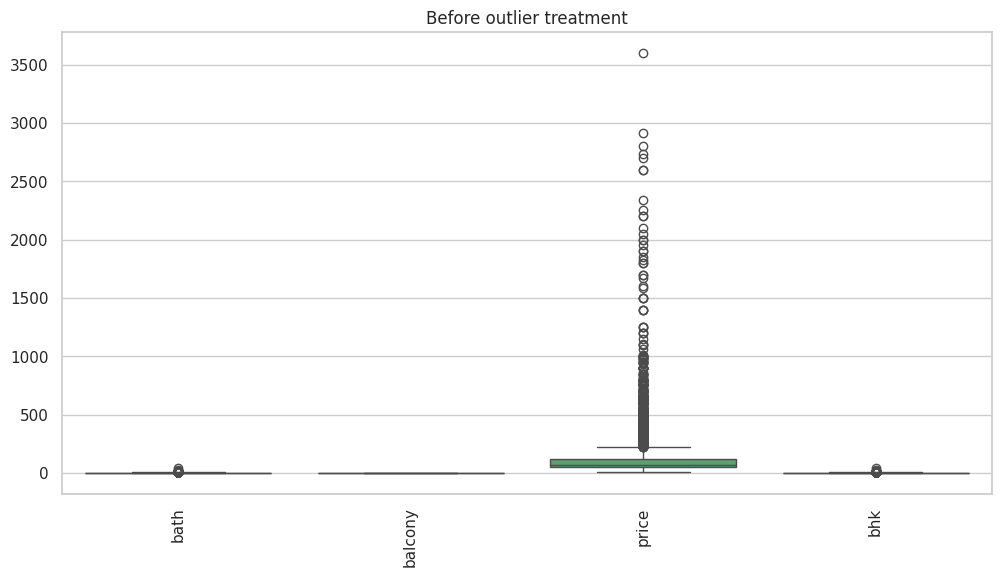

In [ ]:
#Checking for outliers before treatment
plt.figure(figsize=(12, 6))
sns.set(style='whitegrid')

# Create a boxplot of all columns
sns.boxplot(data=processing_data)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)
plt.title('Before outlier treatment')
# Show the plot
plt.show()

In [ ]:
# Calculating 97th percentile for numeric columns only
outliers = processing_data.quantile(0.97, numeric_only=True)

# Removing extreme price outliers
processing_data = processing_data[
    processing_data['price'] <= outliers['price']
]

processing_data.shape

(12855, 8)

In [ ]:
# Check current columns
print(processing_data.columns)

# Convert important columns to numeric safely
processing_data['price'] = pd.to_numeric(processing_data['price'], errors='coerce')
processing_data['bath'] = pd.to_numeric(processing_data['bath'], errors='coerce')
processing_data['balcony'] = pd.to_numeric(processing_data['balcony'], errors='coerce')
processing_data['bhk'] = pd.to_numeric(processing_data['bhk'], errors='coerce')
processing_data['total_sqft'] = pd.to_numeric(processing_data['total_sqft'], errors='coerce')

# Remove missing numeric rows
processing_data = processing_data.dropna(subset=['price', 'bath', 'bhk', 'total_sqft'])

# Calculate outlier limits
outliers = processing_data.quantile(0.97, numeric_only=True)

# Remove outliers only from columns that exist
processing_data = processing_data[processing_data['price'] <= outliers['price']]
processing_data = processing_data[processing_data['bhk'] < 10]
processing_data = processing_data[processing_data['bath'] < 10]
processing_data = processing_data[processing_data['total_sqft'] > 300]

# Check final shape
processing_data.shape

Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'price', 'bhk'],
      dtype='object')


(12317, 8)

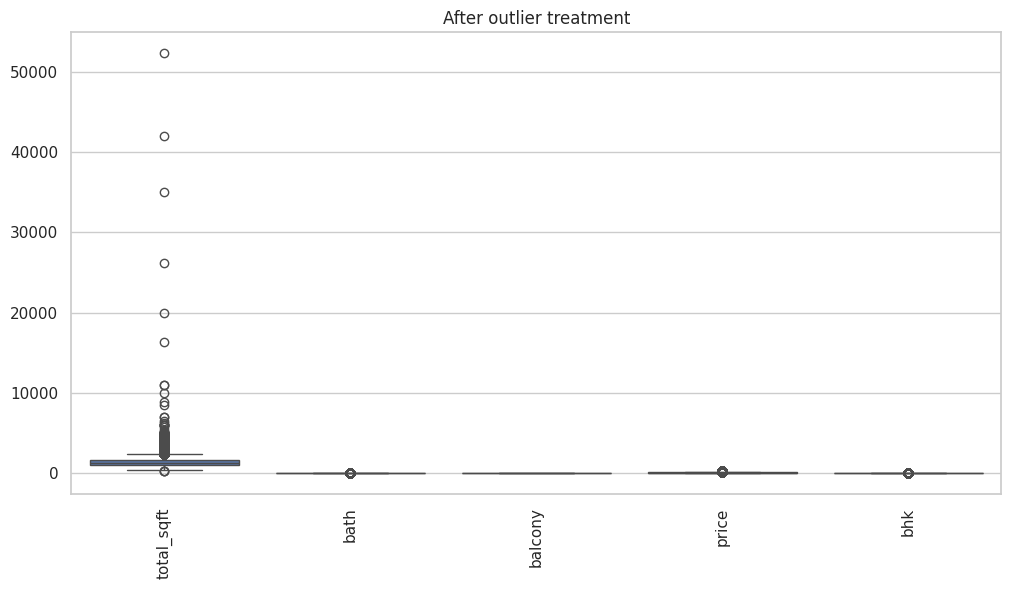

In [ ]:
#Checking for outliers after treatment
plt.figure(figsize=(12, 6))
sns.set(style='whitegrid')

# Create a boxplot of all columns
sns.boxplot(data=processing_data)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)
plt.title('After outlier treatment')

# Show the plot
plt.show()

The dataset is out of outliers now

In [ ]:
processed_data = processing_data

# **Data Visualization**

# Univariate Analysis

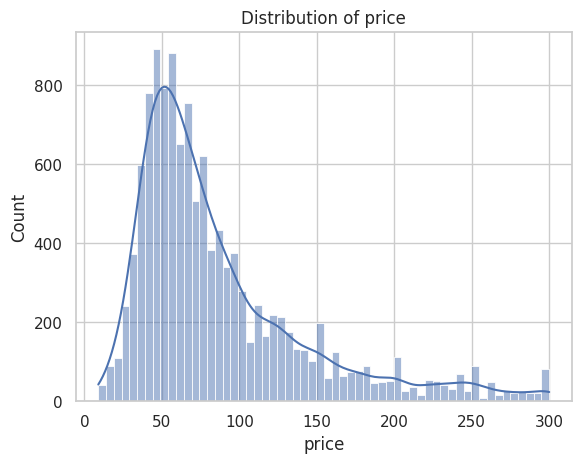

In [ ]:
#target variable analysis of it's distribution
sns.histplot(data=processed_data, x = 'price', kde=True)
plt.title('Distribution of price')
plt.show()

It's right skewed(positive skewness)

Univariate analysis of continuous variables

In [ ]:
# Creating price per square feet column
processing_data['price_per_sqft'] = (
    processing_data['price'] * 100000 / processing_data['total_sqft']
)

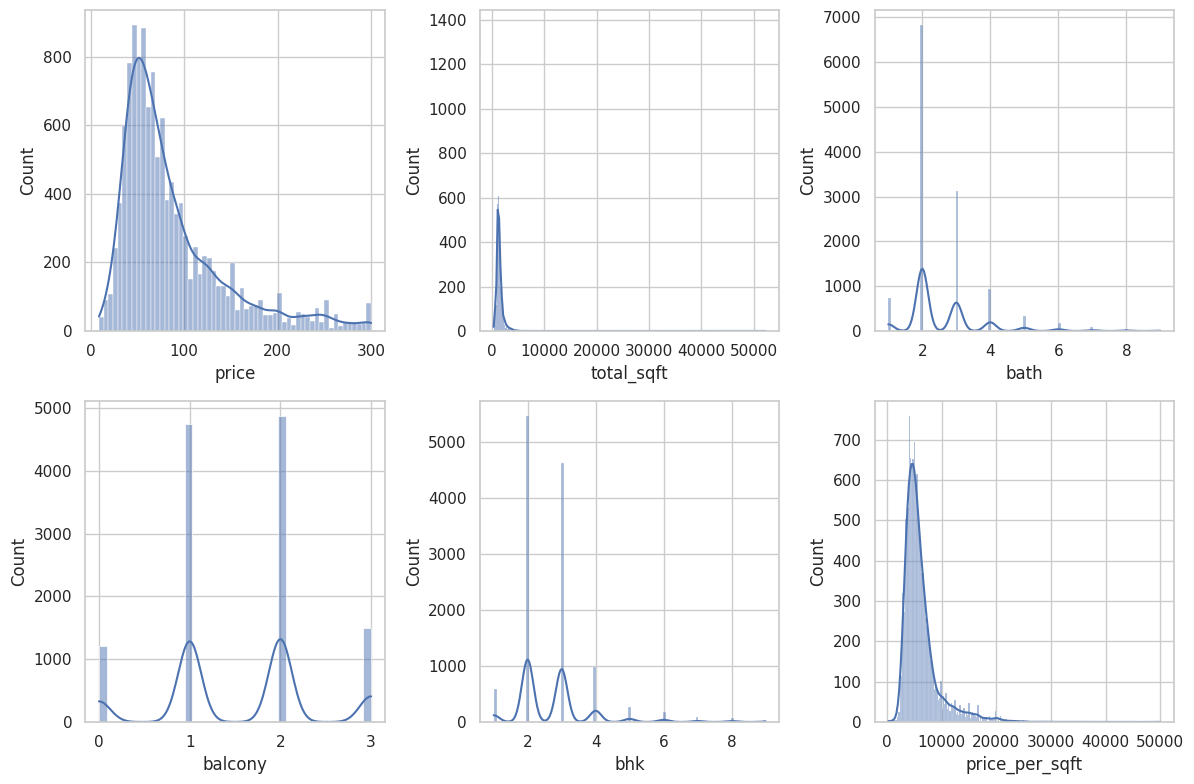

In [ ]:
# Visualizing numerical columns distribution

fig, axes = plt.subplots(2, 3, dpi=100, figsize=(12, 8))

sns.histplot(ax=axes[0,0], data=processing_data, x="price", kde=True)
sns.histplot(ax=axes[0,1], data=processing_data, x="total_sqft", kde=True)
sns.histplot(ax=axes[0,2], data=processing_data, x="bath", kde=True)

sns.histplot(ax=axes[1,0], data=processing_data, x="balcony", kde=True)
sns.histplot(ax=axes[1,1], data=processing_data, x="bhk", kde=True)
sns.histplot(ax=axes[1,2], data=processing_data, x="price_per_sqft", kde=True)

fig.tight_layout()
plt.show()

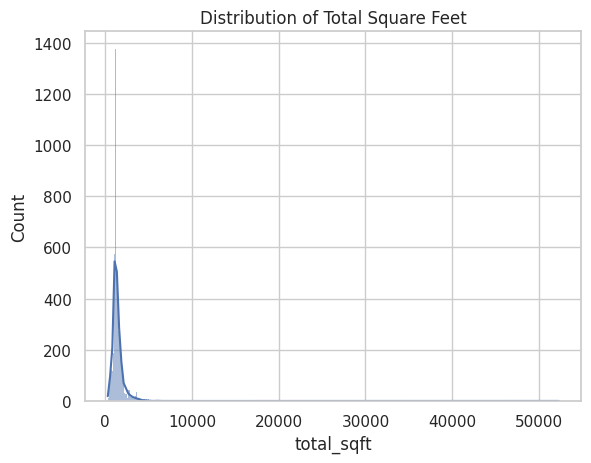

In [ ]:
# Before log transformation the distribution of total_sqft is slightly right skewed

sns.histplot(data=processing_data, x='total_sqft', kde=True)

plt.title("Distribution of Total Square Feet")

plt.show()

Distribution after log transformation


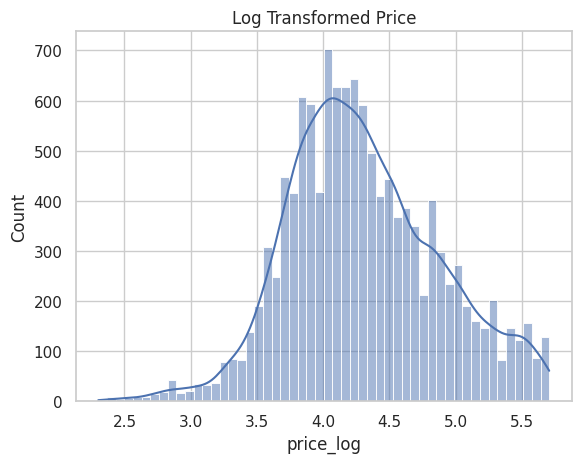

In [ ]:
# Applying log transformation on price

processing_data['price_log'] = np.log1p(processing_data['price'])

print("Distribution after log transformation")

sns.histplot(data=processing_data, x='price_log', kde=True)

plt.title("Log Transformed Price")

plt.show()

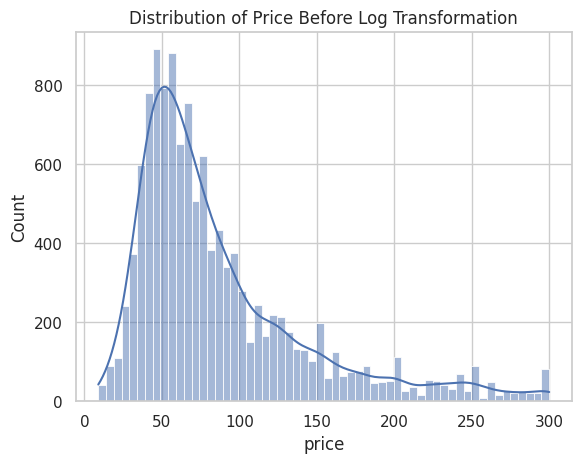

In [ ]:
# Distribution of price before log transformation

sns.histplot(data=processing_data, x='price', kde=True)

plt.title("Distribution of Price Before Log Transformation")

plt.show()

Normally distributed total_sqft


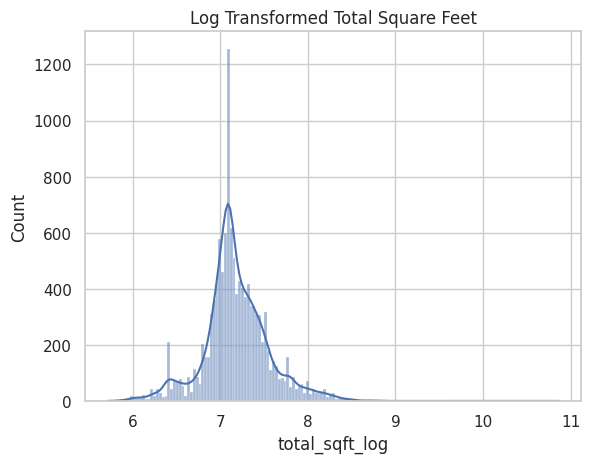

In [ ]:
# Applying log transformation on total square feet

processing_data['total_sqft_log'] = np.log1p(processing_data['total_sqft'])

print("Normally distributed total_sqft")

sns.histplot(data=processing_data, x='total_sqft_log', kde=True)

plt.title("Log Transformed Total Square Feet")

plt.show()

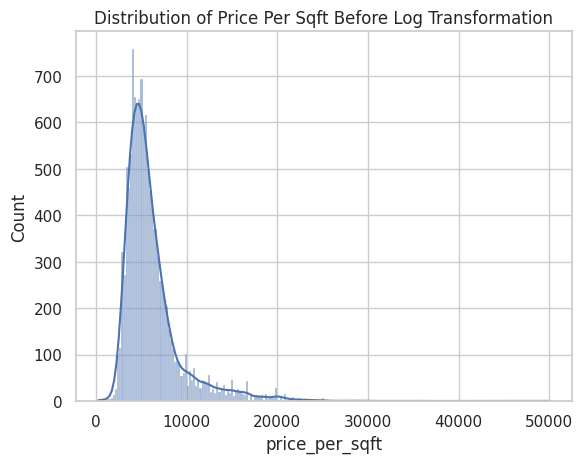

In [ ]:
# Before log transformation the distribution of price_per_sqft is slightly right skewed

sns.histplot(data=processing_data, x='price_per_sqft', kde=True)

plt.title("Distribution of Price Per Sqft Before Log Transformation")

plt.show()

Normally distributed price_per_sqft


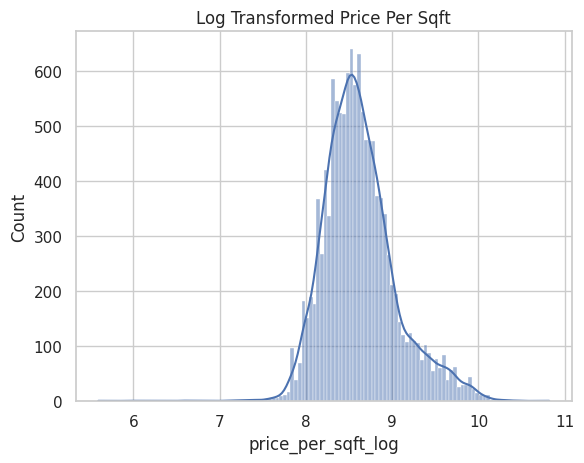

In [ ]:
# Applying log transformation on price_per_sqft

processing_data['price_per_sqft_log'] = np.log1p(
    processing_data['price_per_sqft']
)

print("Normally distributed price_per_sqft")

sns.histplot(
    data=processing_data,
    x='price_per_sqft_log',
    kde=True
)

plt.title("Log Transformed Price Per Sqft")

plt.show()

Univariate analysis of categorical variables

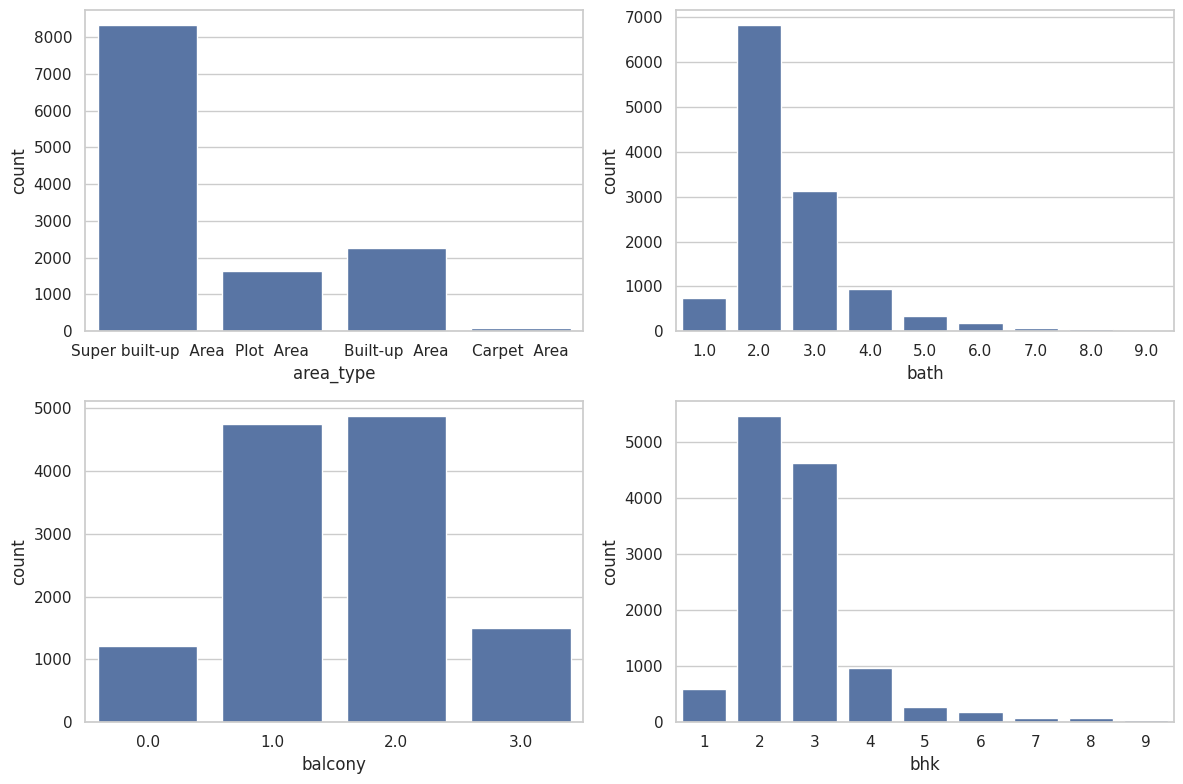

In [ ]:
# Visualizing categorical variables

fig, axes = plt.subplots(2, 2, dpi=100, figsize=(12, 8))

sns.countplot(
    ax=axes[0,0],
    data=processing_data,
    x="area_type"
)

sns.countplot(
    ax=axes[0,1],
    data=processing_data,
    x="bath"
)

sns.countplot(
    ax=axes[1,0],
    data=processing_data,
    x="balcony"
)

sns.countplot(
    ax=axes[1,1],
    data=processing_data,
    x="bhk"
)

fig.tight_layout()

plt.show()

Insights from the analysis:
1. Most of the houses are of one ceiling
2. Most of the houses are not from a coastal region
3. Most of the houses has condition of 3
4. Majority of the houses are not furnished
5. Majority of the houses have built 40 years ago

## Bivariate analysis

Bivariate analysis of numerical features

In [ ]:
# Creating total rooms feature
processing_data['total_rooms'] = (
    processing_data['bhk'] + processing_data['bath']
)

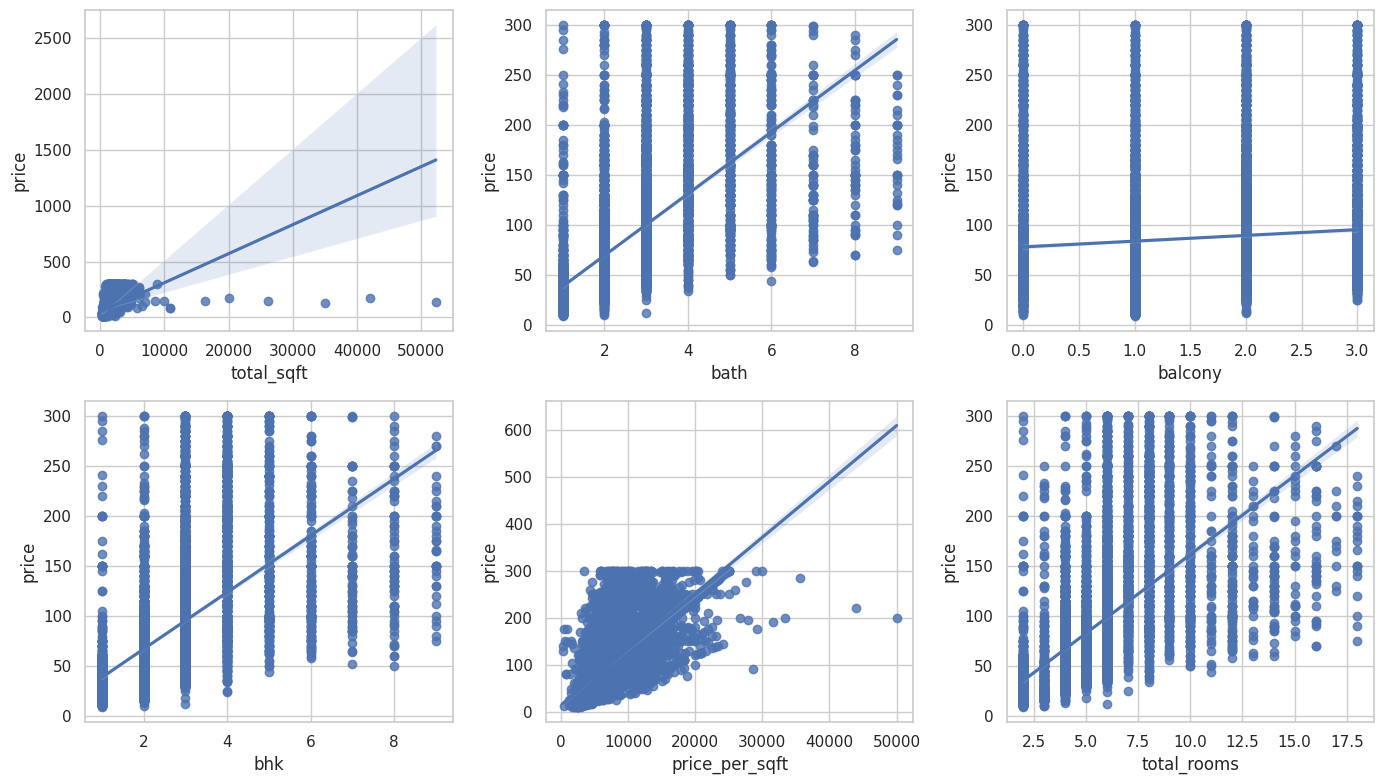

In [ ]:
# Bivariate analysis of numerical variables vs Price

fig, axes = plt.subplots(2, 3, dpi=100, figsize=(14, 8))

sns.regplot(
    ax=axes[0,0],
    data=processing_data,
    x="total_sqft",
    y="price"
)

sns.regplot(
    ax=axes[0,1],
    data=processing_data,
    x="bath",
    y="price"
)

sns.regplot(
    ax=axes[0,2],
    data=processing_data,
    x="balcony",
    y="price"
)

sns.regplot(
    ax=axes[1,0],
    data=processing_data,
    x="bhk",
    y="price"
)

sns.regplot(
    ax=axes[1,1],
    data=processing_data,
    x="price_per_sqft",
    y="price"
)

sns.regplot(
    ax=axes[1,2],
    data=processing_data,
    x="total_rooms",
    y="price"
)

fig.tight_layout()

plt.show()

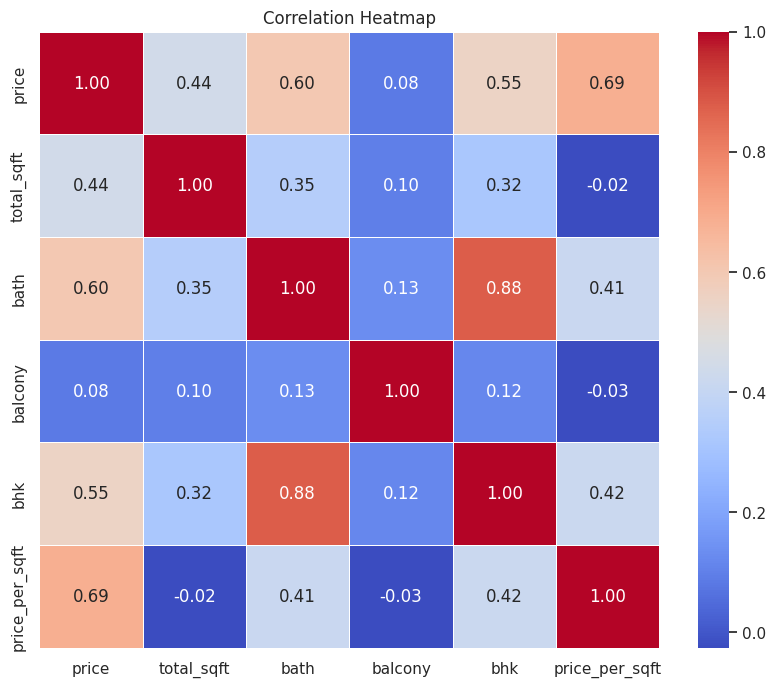

In [ ]:
# Correlation Heatmap for Bengaluru House Dataset

plt.figure(figsize=(10, 8))

heatmap_features = [
    'price',
    'total_sqft',
    'bath',
    'balcony',
    'bhk',
    'price_per_sqft'
]

sns.heatmap(
    processing_data[heatmap_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
# Correlation of numerical features with price

processing_data.select_dtypes(include=['number']).corr()['price'].sort_values(ascending=False)

,price
price,1.00
price_log,0.94
price_per_sqft_log,0.71
price_per_sqft,0.69
total_sqft_log,0.64
bath,0.60
total_rooms,0.60
bhk,0.55
total_sqft,0.44
balcony,0.08


Insights from the heat map of correlations:

living_measure, quality, room_bed, room_bath, lat, living_measure15, ceil_measure all these columns have pretty good correlations in terms of price

### Bivariate analysis for categorical variables

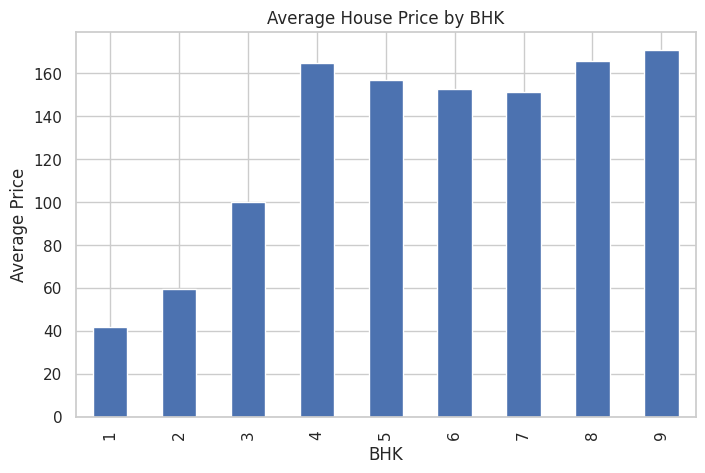

In [ ]:
# Bivariate analysis of BHK vs Price

# Group data by BHK and calculate average price
grouped_data_bhk = processing_data.groupby('bhk')['price'].mean()

# Create bar chart
fig, ax = plt.subplots(figsize=(8,5))

grouped_data_bhk.plot(kind='bar', ax=ax)

ax.set_ylabel('Average Price')
ax.set_xlabel('BHK')
ax.set_title('Average House Price by BHK')

plt.show()

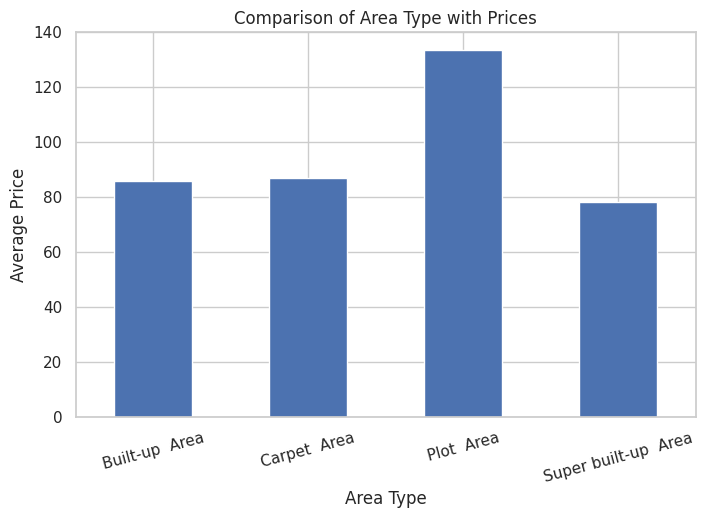

In [ ]:
# Bivariate analysis of area type vs price

# Group data by area_type and calculate average price
grouped_data_area = processing_data.groupby('area_type')['price'].mean()

# Create chart
fig, ax = plt.subplots(figsize=(8,5))

grouped_data_area.plot(kind='bar', ax=ax)

ax.set_ylabel('Average Price')
ax.set_xlabel('Area Type')
ax.set_title('Comparison of Area Type with Prices')

plt.xticks(rotation=15)

plt.show()

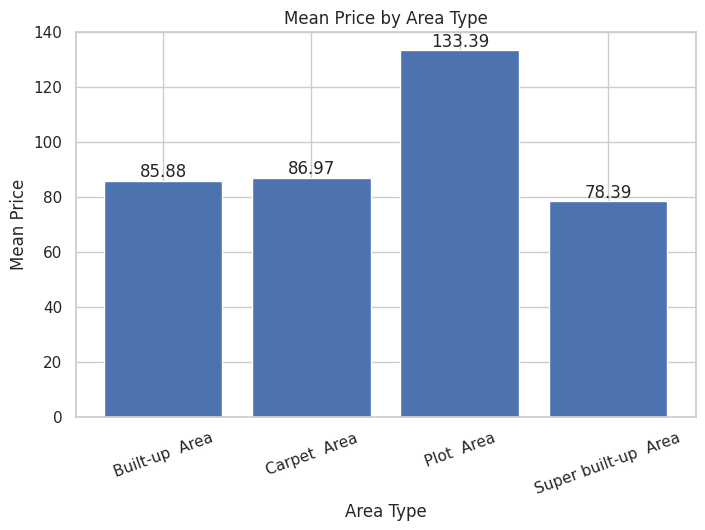

In [ ]:
# Bivariate analysis of area_type vs price

mean_price_by_area = processing_data.groupby('area_type')['price'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

rects = ax.bar(mean_price_by_area.index, mean_price_by_area.values)

ax.set_xlabel('Area Type')
ax.set_ylabel('Mean Price')
ax.set_title('Mean Price by Area Type')

plt.xticks(rotation=20)

ax.bar_label(rects, fmt='%.2f', label_type='edge')

plt.show()

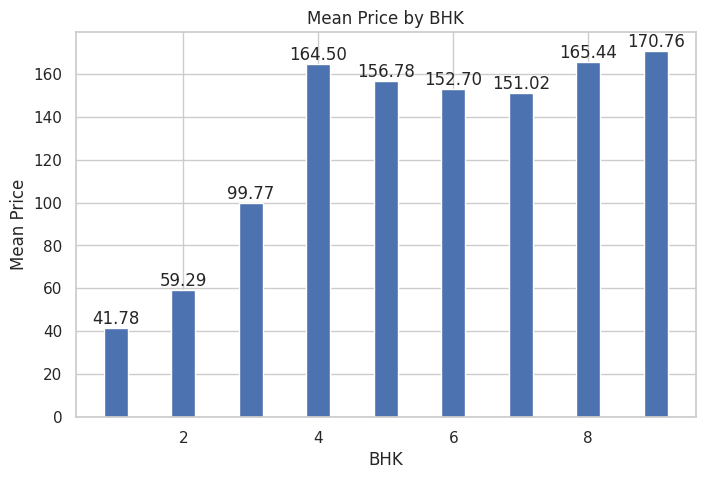

In [ ]:
# Bivariate analysis of BHK vs price

# Calculate mean price for each BHK
mean_price_by_bhk = processing_data.groupby('bhk')['price'].mean()

# Create bar plot
fig, ax = plt.subplots(figsize=(8,5))

conditions = mean_price_by_bhk.index
width = 0.35

rects = ax.bar(conditions, mean_price_by_bhk, width)

ax.set_xlabel('BHK')
ax.set_ylabel('Mean Price')
ax.set_title('Mean Price by BHK')

ax.bar_label(rects, fmt='%.2f', label_type='edge')

plt.show()

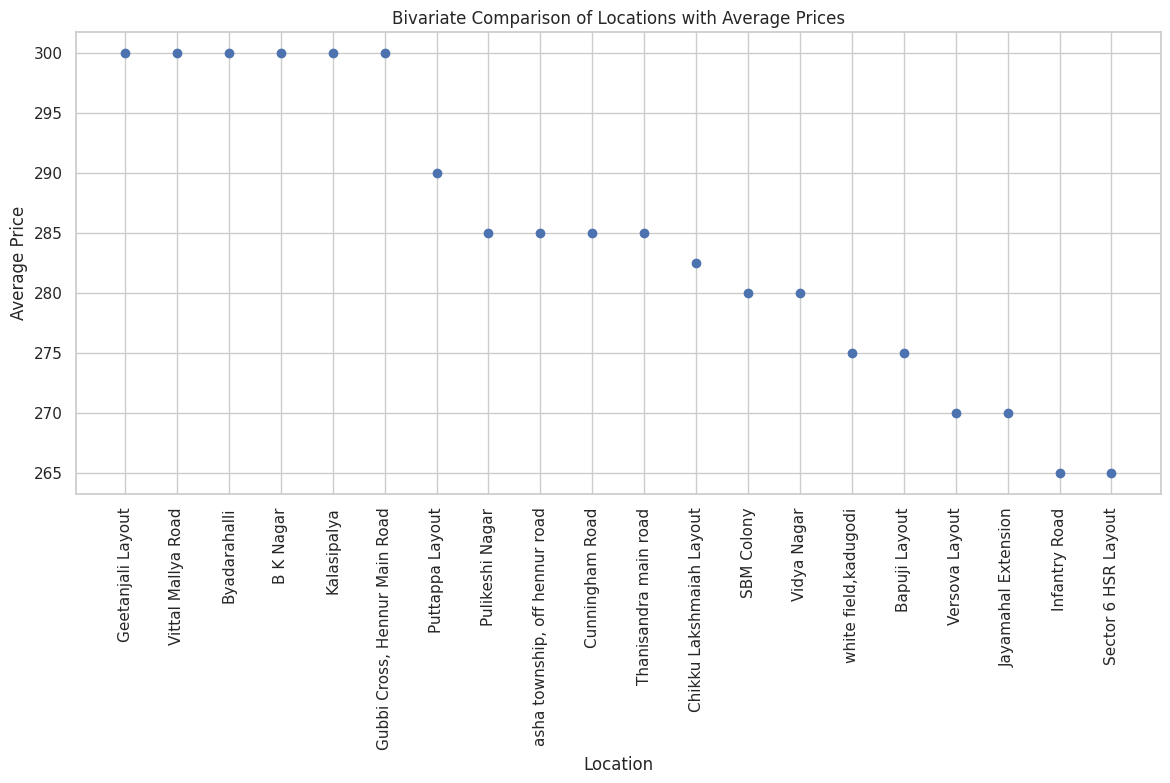

In [ ]:
# Bivariate analysis of location vs price

# Group data by location and calculate average price
grouped_data_location = processing_data.groupby('location')['price'].mean()

# Take top 20 expensive locations for cleaner visualization
grouped_data_location = grouped_data_location.sort_values(
    ascending=False
).head(20)

# Create scatter plot
plt.figure(figsize=(14,6))

plt.scatter(
    grouped_data_location.index,
    grouped_data_location.values
)

plt.xticks(rotation=90)

plt.xlabel('Location')

plt.ylabel('Average Price')

plt.title('Bivariate Comparison of Locations with Average Prices')

plt.show()

# **Future tuning and encoding**

Label encoding

In [ ]:
# Creating a separate dataset for model building
model_data = processing_data.copy()

print("Available columns:")
print(model_data.columns)

Available columns:
Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'price', 'bhk', 'price_per_sqft', 'price_log',
       'total_sqft_log', 'price_per_sqft_log', 'total_rooms'],
      dtype='object')


One hot encoding of city and zipcode column

In [ ]:
# Safe feature preparation for Bengaluru House dataset

numeric_columns = ['price', 'total_sqft', 'bath', 'balcony', 'bhk']

for col in numeric_columns:
    if col in model_data.columns:
        model_data[col] = pd.to_numeric(model_data[col], errors='coerce')

model_data = model_data.dropna(subset=['price', 'total_sqft', 'bath', 'bhk'])

if 'balcony' in model_data.columns:
    model_data['balcony'] = model_data['balcony'].fillna(0)

if 'total_rooms' not in model_data.columns:
    model_data['total_rooms'] = model_data['bhk'] + model_data['bath']

if 'bath_per_bhk' not in model_data.columns:
    model_data['bath_per_bhk'] = model_data['bath'] / model_data['bhk']

if 'balcony_per_bhk' not in model_data.columns:
    model_data['balcony_per_bhk'] = model_data['balcony'] / model_data['bhk']

model_data = model_data.replace([np.inf, -np.inf], np.nan)
model_data = model_data.dropna()

model_data.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,price_log,total_sqft_log,price_per_sqft_log,total_rooms,bath_per_bhk,balcony_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.00,2.00,1.00,39.07,2,3699.81,3.69,6.96,8.22,4.00,1.00,0.50
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.00,5.00,3.00,120.00,4,4615.38,4.80,7.86,8.44,9.00,1.25,0.75
2,Built-up Area,Ready To Move,Uttarahalli,1440.00,2.00,3.00,62.00,3,4305.56,4.14,7.27,8.37,5.00,0.67,1.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.00,3.00,1.00,95.00,3,6245.89,4.56,7.33,8.74,6.00,1.00,0.33
4,Super built-up Area,Ready To Move,Kothanur,1200.00,2.00,1.00,51.00,2,4250.00,3.95,7.09,8.35,4.00,1.00,0.50


In [ ]:
# Encoding categorical features

if 'location' in model_data.columns:
    model_data['location'] = model_data['location'].astype(str).str.strip()

    top_locations = model_data['location'].value_counts().head(30).index
    model_data['location'] = model_data['location'].apply(
        lambda x: x if x in top_locations else 'Other'
    )

if 'availability' in model_data.columns:
    model_data['availability_status'] = np.where(
        model_data['availability'].astype(str).str.lower().str.contains('ready'),
        'Ready To Move',
        'Not Ready'
    )
    model_data = model_data.drop('availability', axis=1)

columns_to_drop = [
    'price_per_sqft',
    'price_per_sqft_log',
    'price_log',
    'total_sqft_log',
    'society'
]

model_data = model_data.drop(columns=columns_to_drop, errors='ignore')

model_data.head()

,area_type,location,total_sqft,bath,balcony,price,bhk,total_rooms,bath_per_bhk,balcony_per_bhk,availability_status
0,Super built-up Area,Electronic City Phase II,1056.00,2.00,1.00,39.07,2,4.00,1.00,0.50,Not Ready
1,Plot Area,Other,2600.00,5.00,3.00,120.00,4,9.00,1.25,0.75,Ready To Move
2,Built-up Area,Uttarahalli,1440.00,2.00,3.00,62.00,3,5.00,0.67,1.00,Ready To Move
3,Super built-up Area,Other,1521.00,3.00,1.00,95.00,3,6.00,1.00,0.33,Ready To Move
4,Super built-up Area,Other,1200.00,2.00,1.00,51.00,2,4.00,1.00,0.50,Ready To Move


## Scaling of features

In [ ]:
scaler = MinMaxScaler()

In [ ]:
# One-hot encoding categorical columns

categorical_columns = model_data.select_dtypes(
    include=['object', 'category']
).columns.tolist()

if 'price' in categorical_columns:
    categorical_columns.remove('price')

model_data_encoded = pd.get_dummies(
    model_data,
    columns=categorical_columns,
    drop_first=True
)

model_data_encoded = model_data_encoded.astype(float)

model_data_encoded.head()

,total_sqft,bath,balcony,price,bhk,total_rooms,bath_per_bhk,balcony_per_bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_Banashankari,location_Bannerghatta Road,location_Begur Road,location_Bellandur,location_Chandapura,location_Electronic City,location_Electronic City Phase II,location_Electronics City Phase 1,location_Haralur Road,location_Harlur,location_Hebbal,location_Hennur Road,location_Hoodi,location_Hormavu,location_KR Puram,location_Kanakpura Road,location_Kasavanhalli,location_Kengeri,location_Marathahalli,location_Other,location_Raja Rajeshwari Nagar,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,availability_status_Ready To Move
0,1056.00,2.00,1.00,39.07,2.00,4.00,1.00,0.50,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2600.00,5.00,3.00,120.00,4.00,9.00,1.25,0.75,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2,1440.00,2.00,3.00,62.00,3.00,5.00,0.67,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
3,1521.00,3.00,1.00,95.00,3.00,6.00,1.00,0.33,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
4,1200.00,2.00,1.00,51.00,2.00,4.00,1.00,0.50,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [ ]:
# One-hot encoding categorical columns

categorical_columns = model_data.select_dtypes(
    include=['object', 'category']
).columns.tolist()

if 'price' in categorical_columns:
    categorical_columns.remove('price')

model_data_encoded = pd.get_dummies(
    model_data,
    columns=categorical_columns,
    drop_first=True
)

model_data_encoded = model_data_encoded.astype(float)

model_data_encoded.head()

,total_sqft,bath,balcony,price,bhk,total_rooms,bath_per_bhk,balcony_per_bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_Banashankari,location_Bannerghatta Road,location_Begur Road,location_Bellandur,location_Chandapura,location_Electronic City,location_Electronic City Phase II,location_Electronics City Phase 1,location_Haralur Road,location_Harlur,location_Hebbal,location_Hennur Road,location_Hoodi,location_Hormavu,location_KR Puram,location_Kanakpura Road,location_Kasavanhalli,location_Kengeri,location_Marathahalli,location_Other,location_Raja Rajeshwari Nagar,location_Ramamurthy Nagar,location_Sarjapur,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,availability_status_Ready To Move
0,1056.00,2.00,1.00,39.07,2.00,4.00,1.00,0.50,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2600.00,5.00,3.00,120.00,4.00,9.00,1.25,0.75,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2,1440.00,2.00,3.00,62.00,3.00,5.00,0.67,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
3,1521.00,3.00,1.00,95.00,3.00,6.00,1.00,0.33,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
4,1200.00,2.00,1.00,51.00,2.00,4.00,1.00,0.50,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


# **Model building**

### Linear Regression

In [ ]:
# Train-test split

X = model_data_encoded.drop('price', axis=1)
y = model_data_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of features:", X_train.shape[1])

X_train shape: (9853, 41)
X_test shape: (2464, 41)
Number of features: 41


In [ ]:
# Scaling features

scaler = MinMaxScaler()

x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [ ]:
#Creating the object for the Linear Regression model
lr=LinearRegression()

In [ ]:
# Model evaluation function

def evaluate_model(model_name, model, x_train, x_test, y_train, y_test):
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    n_features = x_train.shape[1]

    results = {
        'Model': model_name,
        'Train_R2': r2_score(y_train, train_pred),
        'Test_R2': r2_score(y_test, test_pred),
        'Test_Adjusted_R2': adjusted_r2_score(y_test, test_pred, n_features),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train_MAE': mean_absolute_error(y_train, train_pred),
        'Test_MAE': mean_absolute_error(y_test, test_pred)
    }

    return results

In [ ]:
#Fitting the train data into the model
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
#predicting with the x_test
lr_pred_test = lr.predict(x_test)

In [ ]:
#Calculating the r2_score and RMSE for test data
lr_r2_score_test = r2_score(y_test, lr_pred_test)
lr_adj_r2_score_test = adjusted_r2_score(y_test, lr_pred_test, 118)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred_test))

In [ ]:
#Printing the r2_score and RMSE for test data
print(f"Linear Regression R squared test score: {lr_r2_score_test}")
print(f"Linear Regression Adjusted R squared score: {lr_adj_r2_score_test}")
print(f"Linear Regression RMSE: {lr_rmse}")


Linear Regression R squared test score: 0.4988071996616473
Linear Regression Adjusted R squared score: 0.47358726343993063
Linear Regression RMSE: 38.30736815746395


In [ ]:
#Cross validating
k_folds = KFold(n_splits = 5)
scores = cross_val_score(lr, x_train, y_train, cv = k_folds)

print("Cross Validation Scores (Linear Regression): ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores (Linear Regression):  [0.49371715 0.28173163 0.46790034 0.42714701 0.47011439]
Average CV Score:  0.42812210577737897
Number of CV Scores used in Average:  5


In [ ]:
# Linear Regression

lr = LinearRegression()
lr.fit(x_train, y_train)

lr_results = evaluate_model(
    'Linear Regression',
    lr,
    x_train,
    x_test,
    y_train,
    y_test
)

lr_results

{'Model': 'Linear Regression',
 'Train_R2': 0.4615233876995981,
 'Test_R2': 0.4988071996616473,
 'Test_Adjusted_R2': 0.4903229284750774,
 'Train_RMSE': np.float64(41.90037370981233),
 'Test_RMSE': np.float64(38.30736815746395),
 'Train_MAE': 28.140317317328364,
 'Test_MAE': 26.798243778741302}

### Decision Tree

In [ ]:
#Creating an object of the DecisionTreeRegressor
DTR = DecisionTreeRegressor(max_depth=4)

In [ ]:
# Decision Tree Regressor

DTR = DecisionTreeRegressor(max_depth=6, random_state=42)
DTR.fit(x_train, y_train)

dtr_results = evaluate_model(
    'Decision Tree',
    DTR,
    x_train,
    x_test,
    y_train,
    y_test
)

dtr_results

{'Model': 'Decision Tree',
 'Train_R2': 0.6793273086415227,
 'Test_R2': 0.627280278688437,
 'Test_Adjusted_R2': 0.6209708201526096,
 'Train_RMSE': np.float64(32.33444881487938),
 'Test_RMSE': np.float64(33.034754985383564),
 'Train_MAE': 21.763128941891594,
 'Test_MAE': 22.067078173535315}

In [ ]:
#Fitting the train data into the model
DTR.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=6, random_state=42)

In [ ]:
#predicting with the x_test
dtr_pred = DTR.predict(x_test)

In [ ]:
#Calculating the r2_score and RMSE
dtr_r2_score = r2_score(y_test, dtr_pred)
dtr_adj_r2_score = adjusted_r2_score(y_test, dtr_pred, 118)
dtr_rmse = np.sqrt(mean_squared_error(y_test, dtr_pred))

In [ ]:
#Printing the r2_score and RMSE
print(f"Decision Tree Regression R squared test score: {dtr_r2_score}")
print(f"Decision Tree Regression Adjusted R squared test score: {dtr_adj_r2_score}")
print(f"Decision Tree Regression RMSE: {dtr_rmse}")


Decision Tree Regression R squared test score: 0.627280278688437
Decision Tree Regression Adjusted R squared test score: 0.6085250858889639
Decision Tree Regression RMSE: 33.034754985383564


In [ ]:
#Cross validating
k_folds = KFold(n_splits = 5)
scores = cross_val_score(DTR, x_train, y_train, cv = k_folds)

print("Cross Validation Scores (Decision Tree): ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores (Decision Tree):  [0.65925154 0.61048189 0.59255003 0.64096811 0.63817832]
Average CV Score:  0.6282859788541341
Number of CV Scores used in Average:  5


## Ridge Regression

In [ ]:
# Ridge Regression

RGR = Ridge()
RGR.fit(x_train, y_train)

ridge_results = evaluate_model(
    'Ridge Regression',
    RGR,
    x_train,
    x_test,
    y_train,
    y_test
)

ridge_results

{'Model': 'Ridge Regression',
 'Train_R2': 0.45876628689400734,
 'Test_R2': 0.48264888792917415,
 'Test_Adjusted_R2': 0.47389108627975063,
 'Train_RMSE': np.float64(42.00750561981562),
 'Test_RMSE': np.float64(38.91997899182424),
 'Train_MAE': 28.576955262737673,
 'Test_MAE': 27.25084577316718}

In [ ]:
#Fitting the train data into the model
RGR.fit(x_train, y_train)

Ridge()

In [ ]:
#predicting with the x_test
rgr_pred = RGR.predict(x_test)

In [ ]:
#Calculating the r2_score and RMSE
rgr_r2_score = r2_score(y_test, rgr_pred)
rgr_adj_r2_score = adjusted_r2_score(y_test, rgr_pred, 118)
rgr_rmse = np.sqrt(mean_squared_error(y_test, rgr_pred))

In [ ]:
#Printing the r2_score and RMSE
print(f"Ridge Regression R squared test score: {rgr_r2_score}")
print(f"Ridge Regression Adjusted R squared test score: {rgr_adj_r2_score}")
print(f"Ridge Regression RMSE: {rgr_rmse}")


Ridge Regression R squared test score: 0.48264888792917415
Ridge Regression Adjusted R squared test score: 0.4566158682172946
Ridge Regression RMSE: 38.91997899182424


In [ ]:
#Cross validating
k_folds = KFold(n_splits = 5)
scores = cross_val_score(RGR, x_train, y_train, cv = k_folds)

print("Cross Validation Scores (Ridge Regression): ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores (Ridge Regression):  [0.47730147 0.40294189 0.4541058  0.43294943 0.45608234]
Average CV Score:  0.44467618524087793
Number of CV Scores used in Average:  5


## XGB Regressor

In [ ]:
# XGBoost Regressor

XGB = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

XGB.fit(x_train, y_train)

xgb_results = evaluate_model(
    'XGBoost',
    XGB,
    x_train,
    x_test,
    y_train,
    y_test
)

xgb_results

{'Model': 'XGBoost',
 'Train_R2': 0.7359890860369347,
 'Test_R2': 0.677744691393154,
 'Test_Adjusted_R2': 0.6722895024365558,
 'Train_RMSE': np.float64(29.339007226437566),
 'Test_RMSE': np.float64(30.71708106543864),
 'Train_MAE': 19.29649830347679,
 'Test_MAE': 20.33209002250201}

In [ ]:
#Fitting the train data into the model
XGB.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#predicting with the x_test
xgb_pred = XGB.predict(x_test)

In [ ]:
#Calculating the r2_score and RMSE
xgb_r2_score = r2_score(y_test, xgb_pred)
xgb_adj_r2_score = adjusted_r2_score(y_test, xgb_pred, 118)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

In [ ]:
#Printing the r2_score and RMSE
print(f"XGB Regression R squared test score: {xgb_r2_score}")
print(f"XGB Regression Adjusted R squared test score: {xgb_adj_r2_score}")
print(f"XGB Regression RMSE: {xgb_rmse}")


XGB Regression R squared test score: 0.677744691393154
XGB Regression Adjusted R squared test score: 0.66152885923298
XGB Regression RMSE: 30.71708106543864


In [ ]:
#Cross validating
k_folds = KFold(n_splits = 5)
scores = cross_val_score(XGB, x_train, y_train, cv = k_folds)

print("Cross Validation Scores (XGB Regressor): ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores (XGB Regressor):  [0.69866748 0.66516372 0.65558145 0.66506256 0.65566599]
Average CV Score:  0.6680282397895485
Number of CV Scores used in Average:  5


## Light GBM Regressor

In [ ]:
# LightGBM Regressor

LGBM = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

LGBM.fit(x_train, y_train)

lgbm_results = evaluate_model(
    'LightGBM',
    LGBM,
    x_train,
    x_test,
    y_train,
    y_test
)

lgbm_results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 9853, number of used features: 41
[LightGBM] [Info] Start training from score 87.699898


{'Model': 'LightGBM',
 'Train_R2': 0.7561079886401041,
 'Test_R2': 0.6826078471074559,
 'Test_Adjusted_R2': 0.6772349824218266,
 'Train_RMSE': np.float64(28.1989710366283),
 'Test_RMSE': np.float64(30.484424196510446),
 'Train_MAE': 18.555583729773293,
 'Test_MAE': 20.075965555802334}

In [ ]:
#Fitting the train data into the model
LGBM.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 9853, number of used features: 41
[LightGBM] [Info] Start training from score 87.699898


LGBMRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [ ]:
#predicting with the x_test
lgbm_pred = LGBM.predict(x_test)

In [ ]:
#Calculating the r2_score and RMSE
lgbm_r2_score = r2_score(y_test, lgbm_pred)
lgbm_adj_r2_score = adjusted_r2_score(y_test, lgbm_pred, 118)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

In [ ]:
#Printing the r2_score and RMSE
print(f"LGBM Regression R squared test score: {lgbm_r2_score}")
print(f"LGBM Regression Adjusted R squared test score: {lgbm_adj_r2_score}")
print(f"LGBM Regression RMSE: {lgbm_rmse}")


LGBM Regression R squared test score: 0.6826078471074559
LGBM Regression Adjusted R squared test score: 0.6666367281132894
LGBM Regression RMSE: 30.484424196510446


In [ ]:
#Cross validating
k_folds = KFold(n_splits = 5)
scores = cross_val_score(LGBM, x_train, y_train, cv = k_folds)

print("Cross Validation Scores (LGBM Regressor): ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 7882, number of used features: 41
[LightGBM] [Info] Start training from score 87.458579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 7882, number of used features: 41
[LightGBM] [Info] Start training from score 87.143150
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000426 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

## Cat Boost Regressor

In [ ]:
# CatBoost Regressor

CB = cb.CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

CB.fit(x_train, y_train)

catboost_results = evaluate_model(
    'CatBoost',
    CB,
    x_train,
    x_test,
    y_train,
    y_test
)

catboost_results

{'Model': 'CatBoost',
 'Train_R2': 0.7270996113422206,
 'Test_R2': 0.6765530983247418,
 'Test_Adjusted_R2': 0.6710777378917585,
 'Train_RMSE': np.float64(29.828852795073153),
 'Test_RMSE': np.float64(30.773819444241326),
 'Train_MAE': 19.75552511397274,
 'Test_MAE': 20.30060783671319}

In [ ]:
# Creating an object of the CatBoost Regressor
CB = cb.CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, loss_function='RMSE', verbose=0)


In [ ]:
#Fitting the train data into the model
CB.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.1, loss_function='RMSE', verbose=0)

In [ ]:
#predicting with the x_test
cb_pred = CB.predict(x_test)

In [ ]:
#Calculating the r2_score and RMSE
cb_r2_score = r2_score(y_test, cb_pred)
cb_adj_r2_score = adjusted_r2_score(y_test, cb_pred, 118)
cb_rmse = np.sqrt(mean_squared_error(y_test, cb_pred))

In [ ]:
#Printing the r2_score and RMSE
print(f"Cat Boost Regression R2 test score: {cb_r2_score}")
print(f"Cat Boost Regression Adjusted R squared test score: {cb_adj_r2_score}")
print(f"Cat Boost RMSE: {cb_rmse}")


Cat Boost Regression R2 test score: 0.673865911409355
Cat Boost Regression Adjusted R squared test score: 0.657454899702022
Cat Boost RMSE: 30.90138900422489


In [ ]:
#Cross validating
k_folds = KFold(n_splits = 5)
scores = cross_val_score(CB, x_train, y_train, cv = k_folds)

print("Cross Validation Scores (Cat Boost Regressor): ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores (Cat Boost Regressor):  [0.69421872 0.66388694 0.64048666 0.65905746 0.64902011]
Average CV Score:  0.6613339780177477
Number of CV Scores used in Average:  5


In [ ]:
# Cross validation

k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

models_for_cv = {
    'Linear Regression': lr,
    'Ridge Regression': RGR,
    'Decision Tree': DTR,
    'XGBoost': XGB,
    'LightGBM': LGBM,
    'CatBoost': CB
}

for model_name, model in models_for_cv.items():
    scores = cross_val_score(model, x_train, y_train, cv=k_folds, scoring='r2')
    print(f"{model_name} CV R2 Scores:", scores)
    print(f"{model_name} Average CV R2 Score:", scores.mean())
    print("-" * 60)

Linear Regression CV R2 Scores: [0.44672705 0.45831412 0.36430918 0.44722212 0.49460958]
Linear Regression Average CV R2 Score: 0.442236411060234
------------------------------------------------------------
Ridge Regression CV R2 Scores: [0.45564981 0.44288232 0.43034195 0.43849773 0.47900331]
Ridge Regression Average CV R2 Score: 0.4492750258062732
------------------------------------------------------------
Decision Tree CV R2 Scores: [0.65751775 0.61430422 0.62738853 0.65381111 0.64892238]
Decision Tree Average CV R2 Score: 0.640388798718383
------------------------------------------------------------
XGBoost CV R2 Scores: [0.69882216 0.64640548 0.65560493 0.67088175 0.66677541]
XGBoost Average CV R2 Score: 0.6676979477738973
------------------------------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can s

## Model comparisons

In [ ]:
# Comparing all trained models

model_results = pd.DataFrame([
    lr_results,
    dtr_results,
    ridge_results,
    xgb_results,
    lgbm_results,
    catboost_results
])

model_results = model_results.sort_values(
    by='Test_R2',
    ascending=False
)

model_results

,Model,Train_R2,Test_R2,Test_Adjusted_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
4,LightGBM,0.76,0.68,0.68,28.20,30.48,18.56,20.08
3,XGBoost,0.74,0.68,0.67,29.34,30.72,19.30,20.33
5,CatBoost,0.73,0.68,0.67,29.83,30.77,19.76,20.30
1,Decision Tree,0.68,0.63,0.62,32.33,33.03,21.76,22.07
0,Linear Regression,0.46,0.50,0.49,41.90,38.31,28.14,26.80
2,Ridge Regression,0.46,0.48,0.47,42.01,38.92,28.58,27.25


In [ ]:
def algo_test(x,y):

    L = LinearRegression()
    R = Ridge()
    XGBC= XGBRegressor()
    LGBM = lgb.LGBMRegressor()
    CB = cb.CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, loss_function='RMSE', verbose=0)
    DTR = DecisionTreeRegressor(max_depth=4)


    x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

    algos = [L,R,XGBC, LGBM, CB, DTR]
    algo_names = ['Linear','Ridge','XGradientBooting', 'Light GBM', 'Cat Boost', 'Decision Tree']
    train_r_squared = []
    test_r_squared = []
    train_rmse = []
    test_rmse = []
    train_mae = []
    test_mae = []

    result = pd.DataFrame(columns = ['Train_R_Squared','Test_R_Squared','Train_RMSE','Test_RMSE','Train_MAE', 'Test_MAE'],index = algo_names)

    for algo in algos:
        algo.fit(x_train,y_train)
        train_r_squared.append(r2_score(y_train,algo.predict(x_train)))
        test_r_squared.append(r2_score(y_test,algo.predict(x_test)))
        train_rmse.append(mean_squared_error(y_train, algo.predict(x_train))**.5)
        test_rmse.append(mean_squared_error(y_test, algo.predict(x_test))**.5)
        train_mae.append(mean_absolute_error(y_train, algo.predict(x_train)))
        test_mae.append(mean_absolute_error(y_test, algo.predict(x_test)))

    result.Train_R_Squared = train_r_squared
    result.Test_R_Squared = test_r_squared
    result.Train_RMSE = train_rmse
    result.Test_RMSE = test_rmse
    result.Train_MAE= train_mae
    result.Test_MAE= test_mae

    return result.sort_values('Test_R_Squared', ascending=False)


In [ ]:
algo_test(X,y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003801 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 412
[LightGBM] [Info] Number of data points in the train set: 9853, number of used features: 41
[LightGBM] [Info] Start training from score 87.699898


,Train_R_Squared,Test_R_Squared,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
Light GBM,0.74,0.68,29.02,30.52,19.13,20.15
Cat Boost,0.79,0.67,26.06,30.90,17.16,20.16
XGradientBooting,0.80,0.66,25.30,31.58,16.33,20.38
Decision Tree,0.63,0.61,34.92,33.64,23.41,22.81
Linear,0.46,0.50,41.90,38.31,28.14,26.80
Ridge,0.46,0.50,41.90,38.31,28.15,26.81


## Conclusion

After evaluating all the models performance Cat Boost model is considered the best model with the following values:

In [ ]:
#Performance of Cat Boost model
train_r_squared = []
test_r_squared = []
train_rmse = []
test_rmse = []
train_mae = []
test_mae = []
result = pd.DataFrame(columns = ['Train_R_Squared','Test_R_Squared','Train_RMSE','Test_RMSE','Train_MAE', 'Test_MAE'])
train_r_squared.append(r2_score(y_train,CB.predict(x_train)))
test_r_squared.append(r2_score(y_test,CB.predict(x_test)))
train_rmse.append(mean_squared_error(y_train, CB.predict(x_train))**.5)
test_rmse.append(mean_squared_error(y_test, CB.predict(x_test))**.5)
train_mae.append(mean_absolute_error(y_train, CB.predict(x_train)))
test_mae.append(mean_absolute_error(y_test, CB.predict(x_test)))
result.Train_R_Squared = train_r_squared
result.Test_R_Squared = test_r_squared
result.Train_RMSE = train_rmse
result.Test_RMSE = test_rmse
result.Train_MAE= train_mae
result.Test_MAE= test_mae

print('Cat Boost Model Performance')
result

Cat Boost Model Performance


,Train_R_Squared,Test_R_Squared,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
0,0.79,0.67,26.06,30.90,17.16,20.16


## **Model Interpretation and feature importance**

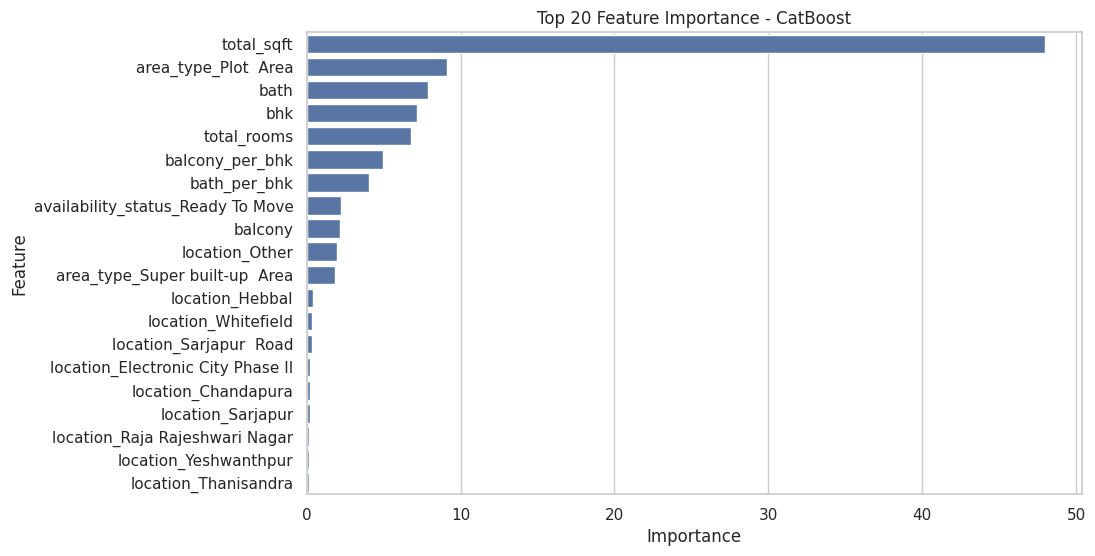

In [ ]:


# Feature Importance
def plot_feature_importance(model, feature_names, top_n=10):
    feature_importance = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Select the top N features
    top_features = feature_importance_df.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top {top_n} Feature Importance - CatBoost')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()


# Print the top 20 features based on importance
plot_feature_importance(CB, X_train.columns, top_n=20)




Insights from the graph:

We are able to clearly see the features that plays an important role in predicting the house price in the cat boost model.  Some features include latitude, living_measure, quality, longitude, living_measure15, etc

## **Ensemble modelling**

In [ ]:
# Create the stacking ensemble as Catboost, Light gbm, linear regression as base model and Ridge regression
# as meta model
base_models = [('catboost', CB), ('lgbm', LGBM), ('linear_reg', lr)]
stacking_model = StackingRegressor(estimators=base_models, final_estimator=RGR)

# Fit the base models
for name, model in base_models:
    model.fit(x_train, y_train)

# Fit the stacking model (meta-model)
stacking_model.fit(x_train, y_train)
stacking_model_pred = stacking_model.predict(x_test)
print(f"R squared score of ensemble model: {r2_score(y_test, stacking_model_pred)}")
print(f"Adjusted R squared score of ensemble model: {adjusted_r2_score(y_test, stacking_model_pred,118)}")
print(f"RMSE of ensemble model: {np.sqrt(mean_squared_error(y_test,stacking_model_pred ))}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 9853, number of used features: 41
[LightGBM] [Info] Start training from score 87.699898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 9853, number of used features: 41
[LightGBM] [Info] Start training from score 87.699898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

# Conclusion

The project successfully predicts Bengaluru house prices using multiple machine learning algorithms.

Among all tested models, the Stacking Ensemble model achieved the best performance by combining CatBoost, LightGBM, and Linear Regression.

The project includes:
- data preprocessing
- feature engineering
- outlier treatment
- visualization
- model comparison
- ensemble learning

This system can help estimate house prices more accurately based on location, area, BHK, bathrooms, and other important features.